In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/johnjoel2001/Bangalore_house_price_prediction/main/Bengaluru_House_Data.csv"
df = pd.read_csv(url)

print("shape:", df.shape)
df.head()


shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
print(df.isna().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [5]:
df = df.drop(columns =["area_type", "availability", "society", "balcony"])
df = df.dropna(subset=["location", "size", "bath"])

In [7]:
df["bhk"] = df["size"].str.extract(r"(\d+)").astype(float)

In [9]:
def convert_sqft(x):
    try:
        if "-"in str(x):
            a, b =str(x).split("-")
            return (float(a)+float(b))/2
        return float(x)
    except:
      return np.nan

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)
df = df.dropna(subset=["total_sqft", "bhk"])

In [10]:
df["price_per_sqft"] = df["price"]*100000/df["total_sqft"]

/tmp/ipykernel_909/1811648217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_per_sqft"] = df["price"]*100000/df["total_sqft"]


In [11]:
anomaly_low_sqft = df[(df["total_sqft"] / df["bhk"]) < 300]

In [12]:
def flag_outliers(group):
    q1, q3 = group["price_per_sqft"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group["price_per_sqft"] < lower) | (group["price_per_sqft"] > upper)]

top_locations = df["location"].value_counts().head(30).index
outliers = pd.concat([flag_outliers(df[df["location"] == loc]) for loc in top_locations])

In [13]:
bad_idx = set(anomaly_low_sqft.index) | set(outliers.index)
df_clean = df.drop(index=bad_idx)
print(f"Flagged {len(bad_idx)} anomalies, {len(bad_idx)/len(df)*100:.1f}% of data")
print(f"Clean dataset: {df_clean.shape[0]} rows")

Flagged 952 anomalies, 7.2% of data
Clean dataset: 12248 rows


In [14]:
loc_stats = df_clean.groupby("location").agg(
    avg_price_per_sqft=("price_per_sqft", "mean"),
    listings=("price_per_sqft", "count")
)
loc_stats = loc_stats[loc_stats["listings"] >= 40].sort_values("avg_price_per_sqft")
print(loc_stats.head(5))       # cheapest
print(loc_stats.tail(5))       # priciest

                          avg_price_per_sqft  listings
location                                              
Chandapura                       2836.118681        87
Electronic City Phase II         3661.106136       125
Begur Road                       3767.304332        74
Attibele                         3939.409114        42
Bisuvanahalli                    4037.179693        50
              avg_price_per_sqft  listings
location                                  
Nagarbhavi           9002.302126        49
Koramangala          9699.577066        67
Rajaji Nagar        13310.366455        98
Malleshwaram        13497.861130        53
Indira Nagar        13916.496675        43


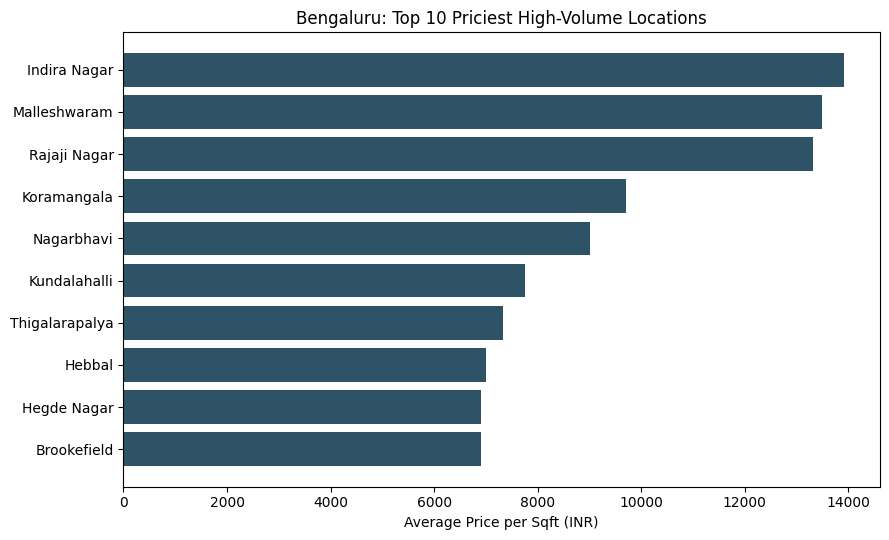

In [15]:
top10 = loc_stats.sort_values("avg_price_per_sqft", ascending=False).head(10).sort_values("avg_price_per_sqft")
plt.figure(figsize=(9, 5.5))
plt.barh(top10.index, top10["avg_price_per_sqft"], color="#2E5266")
plt.xlabel("Average Price per Sqft (INR)")
plt.title("Bengaluru: Top 10 Priciest High-Volume Locations")
plt.tight_layout()
plt.show()